In [6]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [7]:
df=pd.read_csv(r"C:\Users\ishani\OneDrive\Desktop\ishani-personal\project\loan_prdiction\loan_approval_dataset.csv")

In [8]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [12]:
df=df.drop(columns=['loan_id'])

KeyError: "['loan_id'] not found in axis"

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0    no_of_dependents          4269 non-null   int64
 1    education                 4269 non-null   str  
 2    self_employed             4269 non-null   str  
 3    income_annum              4269 non-null   int64
 4    loan_amount               4269 non-null   int64
 5    loan_term                 4269 non-null   int64
 6    cibil_score               4269 non-null   int64
 7    residential_assets_value  4269 non-null   int64
 8    commercial_assets_value   4269 non-null   int64
 9    luxury_assets_value       4269 non-null   int64
 10   bank_asset_value          4269 non-null   int64
 11   loan_status               4269 non-null   str  
dtypes: int64(9), str(3)
memory usage: 498.3 KB


In [ ]:
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [ ]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


EDA

<Axes: xlabel='count', ylabel=' loan_status'>

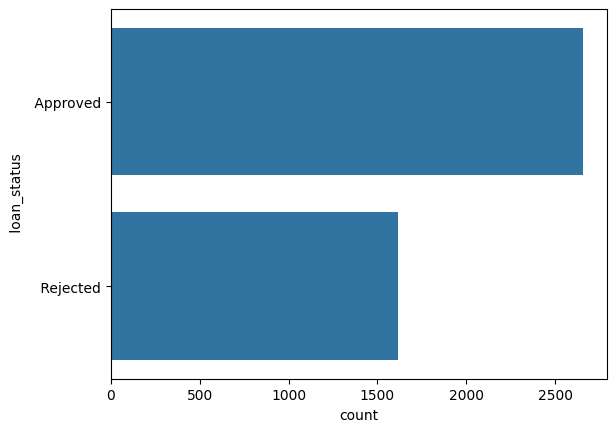

In [ ]:
sns.countplot(df[' loan_status'])

<Axes: xlabel=' loan_status', ylabel=' residential_assets_value'>

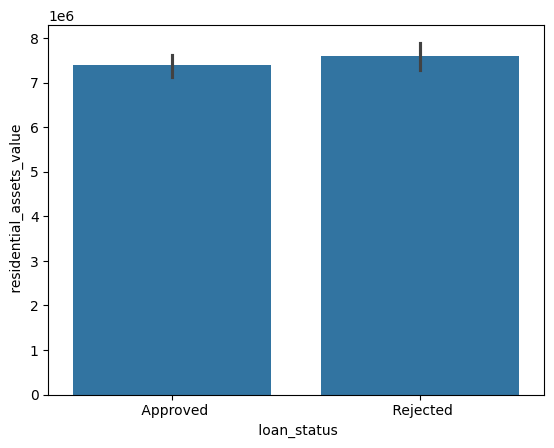

In [ ]:
sns.barplot(data=df ,x=df[' loan_status'],y=df[' residential_assets_value'])

In [ ]:
sns.barplot(data=df ,x=df[' loan_status'],y=df[' education'])

NameError: name 'sns' is not defined

<Axes: xlabel=' loan_status', ylabel=' loan_amount'>

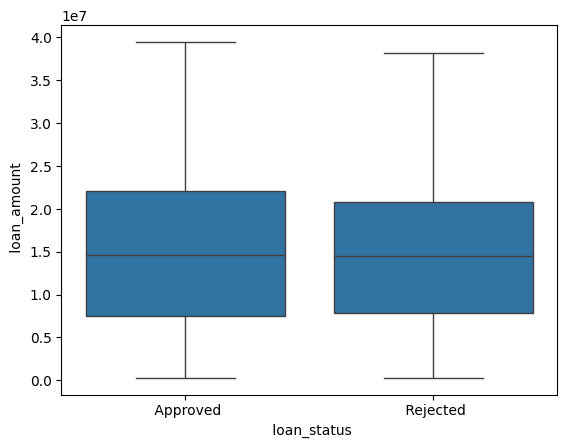

In [ ]:
sns.boxplot(data=df ,x=df[' loan_status'],y=df[' loan_amount'])

In [ ]:
df['total_asset']=(df[' residential_assets_value']+df[' commercial_assets_value']+df[' luxury_assets_value']+df[' bank_asset_value'])

In [ ]:
categorical_features = [' education', ' self_employed']

numerical_features = [
    ' no_of_dependents',
    ' income_annum',
    ' loan_amount',
    ' loan_term',
    ' cibil_score',
    ' residential_assets_value',
    ' commercial_assets_value',
    ' luxury_assets_value',
    ' bank_asset_value',
    'total_asset'
]

target = ' loan_status'

In [ ]:
print(df[categorical_features].head())
print(df[numerical_features].head())

       education self_employed
0       Graduate            No
1   Not Graduate           Yes
2       Graduate            No
3       Graduate            No
4   Not Graduate           Yes
    no_of_dependents   income_annum   loan_amount   loan_term   cibil_score  \
0                  2        9600000      29900000          12           778   
1                  0        4100000      12200000           8           417   
2                  3        9100000      29700000          20           506   
3                  3        8200000      30700000           8           467   
4                  5        9800000      24200000          20           382   

    residential_assets_value   commercial_assets_value   luxury_assets_value  \
0                    2400000                  17600000              22700000   
1                    2700000                   2200000               8800000   
2                    7100000                   4500000              33300000   
3                  

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
print(df.columns.tolist())

[' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status', 'total_asset']


In [ ]:
x=df[categorical_features+numerical_features]
y=df[target]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [ ]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_asset,loan_status_en
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,50700000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,17000000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,57700000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,52700000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,55000000,1


<Axes: xlabel='total_asset', ylabel='Count'>

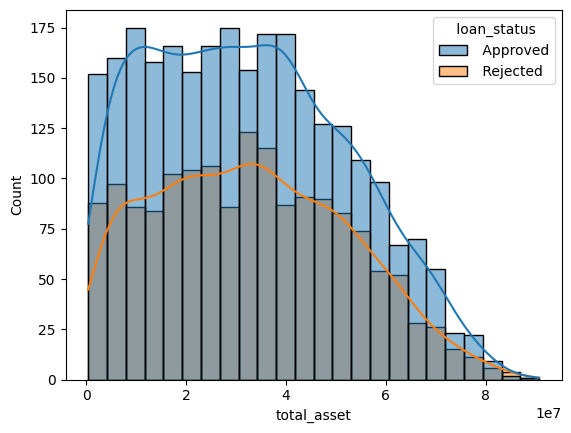

In [ ]:
sns.histplot(data=df,x=df['total_asset'],hue=df[' loan_status'],kde=True)

In [ ]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_asset,loan_status_en
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,50700000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,17000000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,57700000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,52700000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,55000000,1


In [ ]:
df.drop(columns=[' loan_status'],inplace=True)

In [ ]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,total_asset,loan_status_en
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,50700000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,17000000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,57700000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,52700000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,55000000,1


In [ ]:
loan_income_ratio=df[' loan_amount']/df[' income_annum']

<Axes: xlabel='None', ylabel='Count'>

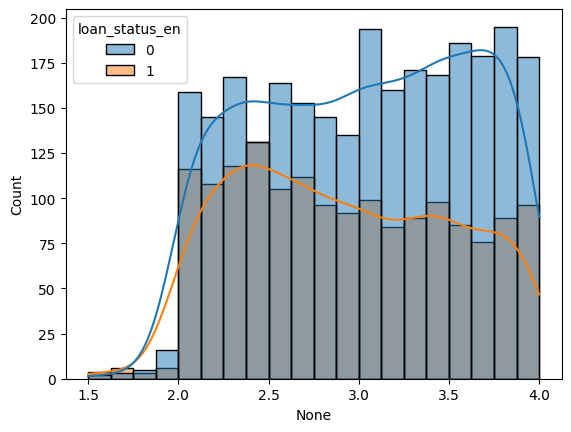

In [ ]:
sns.histplot(data=df,x=loan_income_ratio,hue=df['loan_status_en'],kde=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [ ]:
x.shape

(4269, 12)

In [ ]:
y.shape

(4269,)

In [ ]:
x_train.shape

(3415, 12)

In [ ]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier



In [ ]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,confusion_matrix,recall_score



Logistic

In [ ]:
log=LogisticRegression()
log.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
y_pred=log.predict(x_test_scaled)

In [ ]:
print("accuracy : ",accuracy_score(y_test,y_pred)*100,"%")
print("precision score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred)) 
print("f1 score: ",f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


accuracy :  90.5152224824356 %
precision score:  0.8785942492012779
recall score:  0.8647798742138365
f1 score:  0.8716323296354992
[[498  38]
 [ 43 275]]


KNN


In [ ]:
score=[]
for i in range (1,16):
 knn=KNeighborsClassifier(n_neighbors=i)
 knn.fit(x_train,y_train)
 y_pred=knn.predict(x_test)
 

 score.append(accuracy_score(y_test,y_pred))

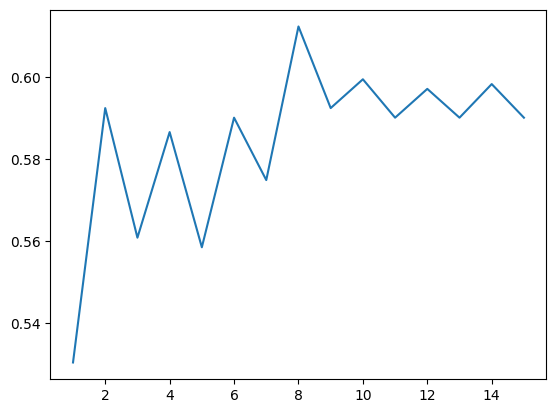

In [ ]:
plt.plot(range(1,16),score)

In [ ]:
knn=KNeighborsClassifier(n_neighbors=8)
knn.fit(x_train,y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",8
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
y_pred2=knn.predict(x_test)

In [ ]:
print("accuracy : ",accuracy_score(y_test,y_pred2)*100,"%")
print("precision score: ",precision_score(y_test,y_pred2))
print("recall score: ",recall_score(y_test,y_pred2)) 
print("f1 score: ",f1_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))


accuracy :  61.241217798594846 %
precision score:  0.4434782608695652
recall score:  0.16037735849056603
f1 score:  0.23556581986143188
[[472  64]
 [267  51]]


svm

In [ ]:
svc=SVC(kernel='rbf')
svc.fit(x_train_scaled,y_train)
y_pred3=svc.predict(x_test_scaled)

In [ ]:
print("accuracy : ",accuracy_score(y_test,y_pred3)*100,"%")
print("precision score: ",precision_score(y_test,y_pred3))
print("recall score: ",recall_score(y_test,y_pred3)) 
print("f1 score: ",f1_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

accuracy :  92.62295081967213 %
precision score:  0.8851963746223565
recall score:  0.9213836477987422
f1 score:  0.9029275808936826
[[498  38]
 [ 25 293]]


decision tree


In [ ]:
dt=DecisionTreeClassifier(criterion='gini',max_depth=5, random_state=42)
dt.fit(x_train,y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [ ]:
y_pred4=dt.predict(x_test)

In [ ]:
print("accuracy : ",accuracy_score(y_test,y_pred4)*100,"%")
print("precision score: ",precision_score(y_test,y_pred4))
print("recall score: ",recall_score(y_test,y_pred4)) 
print("f1 score: ",f1_score(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))

accuracy :  97.18969555035129 %
precision score:  0.9454545454545454
recall score:  0.9811320754716981
f1 score:  0.9629629629629629
[[518  18]
 [  6 312]]


grAadient bossting


In [ ]:
gd=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=5,random_state=42)
gd.fit(x_train,y_train)

,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [ ]:
y_pred5=gd.predict(x_test)

In [ ]:
print("accuracy : ",accuracy_score(y_test,y_pred5)*100,"%")
print("precision score: ",precision_score(y_test,y_pred5))
print("recall score: ",recall_score(y_test,y_pred5)) 
print("f1 score: ",f1_score(y_test,y_pred5))
print(confusion_matrix(y_test,y_pred5))

accuracy :  98.47775175644028 %
precision score:  0.9841269841269841
recall score:  0.9748427672955975
f1 score:  0.9794628751974723
[[531   5]
 [  8 310]]


random forest

In [ ]:
rd=RandomForestClassifier(n_estimators=100,criterion='gini',max_depth=6,random_state=42)
rd.fit(x_train,y_train)
y_pred6=rd.predict(x_test)

In [ ]:
print("accuracy : ",accuracy_score(y_test,y_pred6)*100,"%")
print("precision score: ",precision_score(y_test,y_pred6))
print("recall score: ",recall_score(y_test,y_pred6)) 
print("f1 score: ",f1_score(y_test,y_pred6))
print(confusion_matrix(y_test,y_pred6))

accuracy :  96.4871194379391 %
precision score:  0.9528301886792453
recall score:  0.9528301886792453
f1 score:  0.9528301886792453
[[521  15]
 [ 15 303]]


since random forest, gradient boost, decision tree are performin better therfore we grid search tem 

random forest 

In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
parameters={
    'n_estimators':[100,200,300],
    'max_depth':[5,6,7],
    'max_features':['auto','sqrt','log2'],
    'max_samples':[0.5,0.75,1.0]
}

In [ ]:
grid_rd=GridSearchCV(estimator=rd,param_grid=parameters,cv=5)

In [ ]:
grid_rd.fit(x_train,y_train)

c:\Users\ishani\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
135 fits failed out of a total of 405.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
135 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ishani\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ishani\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 6, ...], 'max_features': ['auto', 'sqrt', ...], 'max_samples': [0.5, 0.75, ...], 'n_estimators': [100, 200, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tru

In [ ]:
print(grid_rd.best_params_)

{'max_depth': 7, 'max_features': 'sqrt', 'max_samples': 1.0, 'n_estimators': 300}


In [ ]:
print(grid_rd.best_score_)

0.9751098096632503


In [ ]:
best_rd=grid_rd.best_estimator_

In [ ]:
y_pred_rd=best_rd.predict(x_test)

In [ ]:
print("accuracy : ",accuracy_score(y_test,y_pred_rd)*100,"%")
print("precision score: ",precision_score(y_test,y_pred_rd))
print("recall score: ",recall_score(y_test,y_pred_rd)) 
print("f1 score: ",f1_score(y_test,y_pred_rd))
print(confusion_matrix(y_test,y_pred_rd))

accuracy :  97.30679156908664 %
precision score:  0.9712460063897763
recall score:  0.9559748427672956
f1 score:  0.9635499207606973
[[527   9]
 [ 14 304]]


grdaient boosting 

In [ ]:
params_gb={
    'n_estimators':[100,200,300],
    'max_depth':[5,6,7],    
    'learning_rate':[0.01,0.1],
    
}

In [ ]:
grid_gb=GridSearchCV(estimator=gd,param_grid=params_gb,cv=5,n_jobs=-1,verbose=1)

In [ ]:
grid_gb.fit(x_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [5, 6, ...], 'n_estimators': [100, 200, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_searc

In [ ]:
print(grid_gb.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


In [ ]:
print(grid_gb.best_score_)

0.9844802342606149


In [ ]:
best_gb=grid_gb.best_estimator_

In [ ]:
best_gb.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [ ]:
y_pred_gb=best_gb.predict(x_test)

In [ ]:
print("accuracy : ",accuracy_score(y_test,y_pred_gb)*100,"%")
print("precision score: ",precision_score(y_test,y_pred_gb))
print("recall score: ",recall_score(y_test,y_pred_gb)) 
print("f1 score: ",f1_score(y_test,y_pred_gb))
print(confusion_matrix(y_test,y_pred_gb))

accuracy :  98.36065573770492 %
precision score:  0.9840764331210191
recall score:  0.9716981132075472
f1 score:  0.9778481012658228
[[531   5]
 [  9 309]]


In [ ]:
comparision=pd.DataFrame({
  'Model':['RandomForestClassifier','GradientBoostingClassifier'],

    'Accuracy':[accuracy_score(y_test,y_pred_rd)*100,accuracy_score(y_test,y_pred_gb)*100],

    'Precision':[precision_score(y_test,y_pred_rd),precision_score(y_test,y_pred_gb)],

    'Recall':[recall_score(y_test,y_pred_rd),recall_score(y_test,y_pred_gb)]    ,

     'f1 score':[f1_score(y_test,y_pred_rd),f1_score(y_test,y_pred_gb)]
})

In [ ]:
print(comparision)

                        Model   Accuracy  Precision    Recall  f1 score
0      RandomForestClassifier  97.306792   0.971246  0.955975  0.963550
1  GradientBoostingClassifier  98.360656   0.984076  0.971698  0.977848


since more gradient boosting accuracy therefoere used as a final model

In [ ]:
final_model=best_gb

In [ ]:
final_model.fit(x_train,y_train)
final_pred=final_model.predict(x_test)

In [ ]:
importance=pd.DataFrame({
    "feature":x_train.columns,
    "importance":final_model.feature_importances_
})
importance=importance.sort_values(ascending=False,by="importance")
print(importance)

                      feature  importance
6                 cibil_score    0.831640
5                   loan_term    0.082747
4                 loan_amount    0.038597
3                income_annum    0.023436
11                total_asset    0.010123
7    residential_assets_value    0.004164
0            no_of_dependents    0.002651
10           bank_asset_value    0.002516
9         luxury_assets_value    0.002248
8     commercial_assets_value    0.001605
2               self_employed    0.000228
1                   education    0.000044


<BarContainer object of 12 artists>

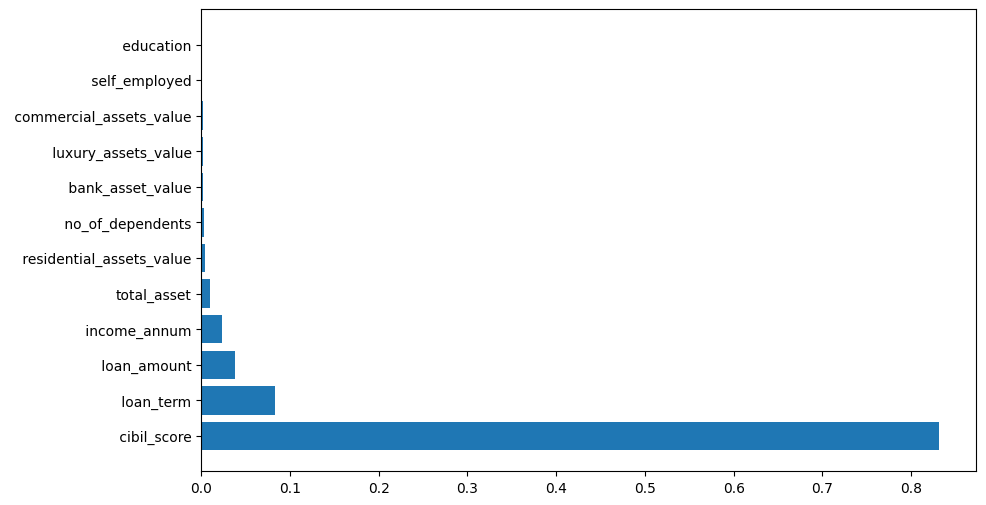

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(importance['feature'], importance['importance'])

In [ ]:
print(x_train.shape)
print(x_train.dtypes)

(3415, 12)
 no_of_dependents            int64
 education                   int64
 self_employed               int64
 income_annum                int64
 loan_amount                 int64
 loan_term                   int64
 cibil_score                 int64
 residential_assets_value    int64
 commercial_assets_value     int64
 luxury_assets_value         int64
 bank_asset_value            int64
total_asset                  int64
dtype: object


In [ ]:
print(df[' education'].unique())
print(df[' self_employed'].unique())

[0 1]
[0 1]


In [ ]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_gb)
])

In [ ]:
final_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","[' Approved',' Rejected']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","[' education',' self_employed',' no_of_dependents',..., ' luxury_assets_value',' bank_asset_value','total_asset']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [ ]:
y_pred_pipeline = final_pipeline.predict(x_test)

In [ ]:
print("accuracy  ",accuracy_score(y_test, y_pred_pipeline))
print("f1",f1_score(y_test, y_pred_pipeline,pos_label=' Approved'))

accuracy   0.9871194379391101
f1 0.9897483690587139


In [ ]:
import joblib
joblib.dump(final_pipeline, "loan_model_pipeline.pkl")

['loan_model_pipeline.pkl']

In [ ]:
import